# Plot: significant hits by channel / feature type

Loads the channel/feature-type breakdown from `explore_leads.ipynb` (`results/leads/{organoid,single_cell}_channel_feature_breakdown.parquet`) and plots a heatmap of which measurement families are being perturbed.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/leads")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/leads")

breakdowns = {
    name: pd.read_parquet(results_path / f"{name}_channel_feature_breakdown.parquet")
    for name in ["organoid", "single_cell"]
}

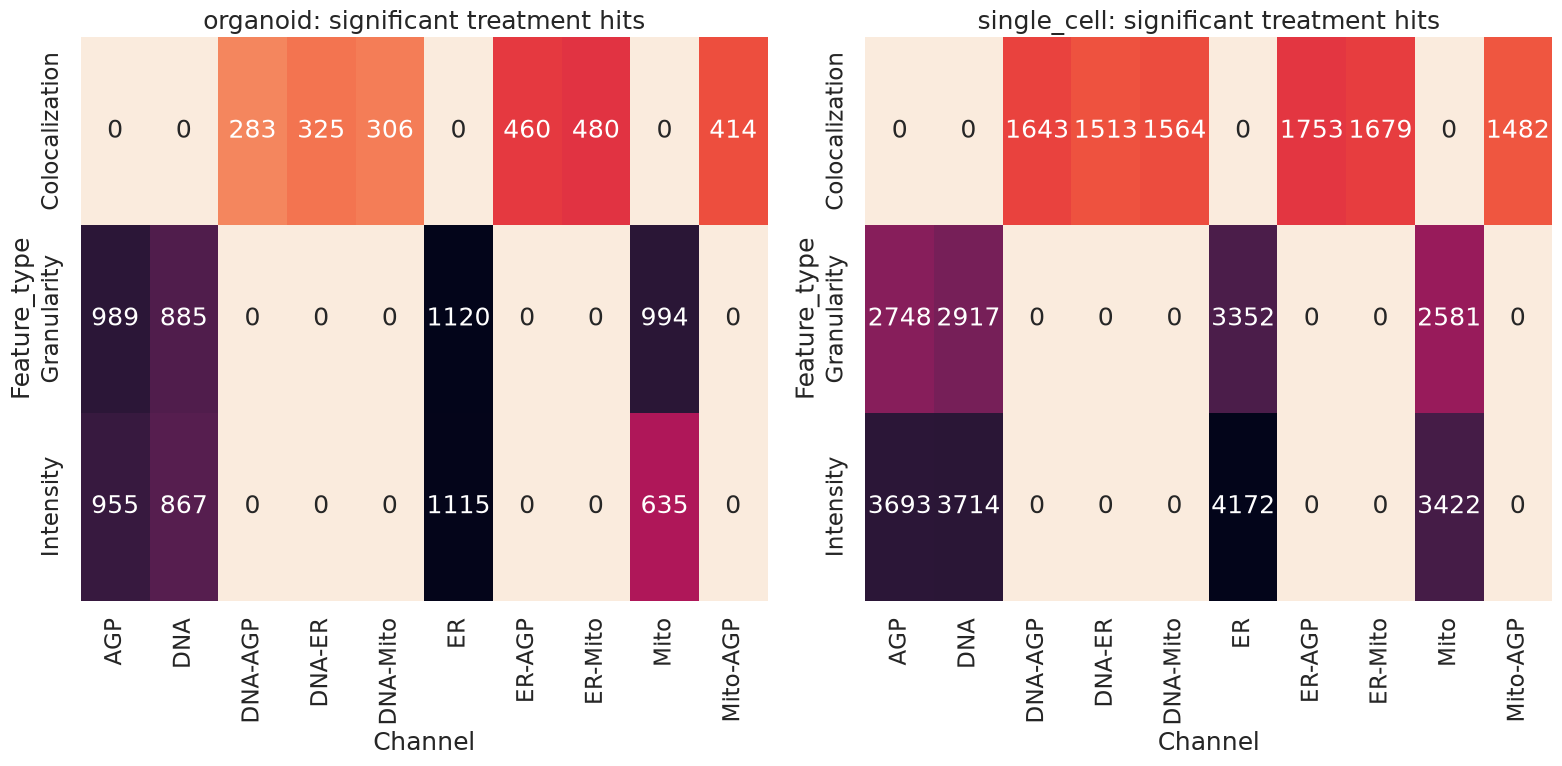

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (name, breakdown) in zip(axes, breakdowns.items()):
    pivot = breakdown.pivot_table(
        index="Feature_type",
        columns="Channel",
        values="n_significant_hits",
        fill_value=0,
    )
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="rocket_r", ax=ax, cbar=False)
    ax.set_title(f"{name}: significant treatment hits")
plt.tight_layout()
plt.savefig(figures_path / "channel_feature_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()